Loaded dataset:


,Open,High,Low,Close,Volume,RV_daily_sq,RV_21,Parkinson_21,log_ret,RV_target,...,parkinson,garman_klass,regime_high_vol,vol_spike,ret_spike,VIX_level,VIX_change,vol_of_vol,GARCH_vol_forecast,HAR_RV_forecast
Date,,,,,,,,,,,,,,,,,,,,,
2023-04-26,18.660000,19.610001,17.870001,18.840000,0,0.000018,0.163710,0.200321,0.004255,0.163710,...,0.003114,0.004281,0,0,0,18.840000,0.004264,-0.049803,0.075682,0.000918
2023-04-27,18.430000,18.430000,16.719999,17.030001,0,0.010202,0.189838,0.204132,-0.101006,0.189838,...,0.003420,0.002330,0,0,1,17.030001,-0.096072,0.159598,0.068660,0.000768
2023-04-28,17.209999,17.650000,15.720000,15.780000,0,0.005812,0.199895,0.215362,-0.076233,0.199895,...,0.004837,0.003798,0,0,1,15.780000,-0.073400,0.052977,0.077984,0.001116
2023-05-01,16.410000,16.620001,15.530000,16.080000,0,0.000355,0.200712,0.215868,0.018833,0.200712,...,0.001660,0.002141,0,0,0,16.080000,0.019011,0.004086,0.077764,0.001217
2023-05-02,16.270000,19.809999,16.260000,17.780001,0,0.010100,0.223824,0.244611,0.100498,0.223824,...,0.014065,0.016456,0,0,1,17.780001,0.105721,0.115151,0.070892,0.001135



Train size: 491, Test size: 123
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 30, 64)            17408     
                                                                 
 dropout_1 (Dropout)         (None, 30, 64)            0         
                                                                 
 lstm_3 (LSTM)               (None, 32)                12416     
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 30369 (118.63 KB)
Trainable params: 30369 (118.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________

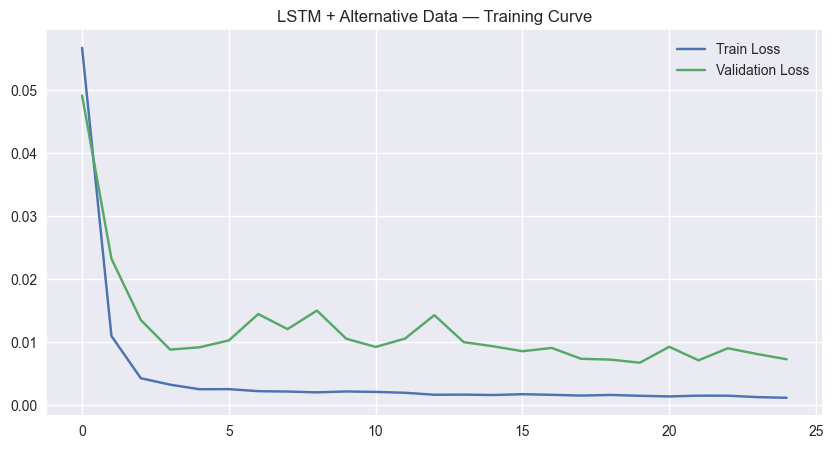

4/4 [==============================] - 1s 7ms/step


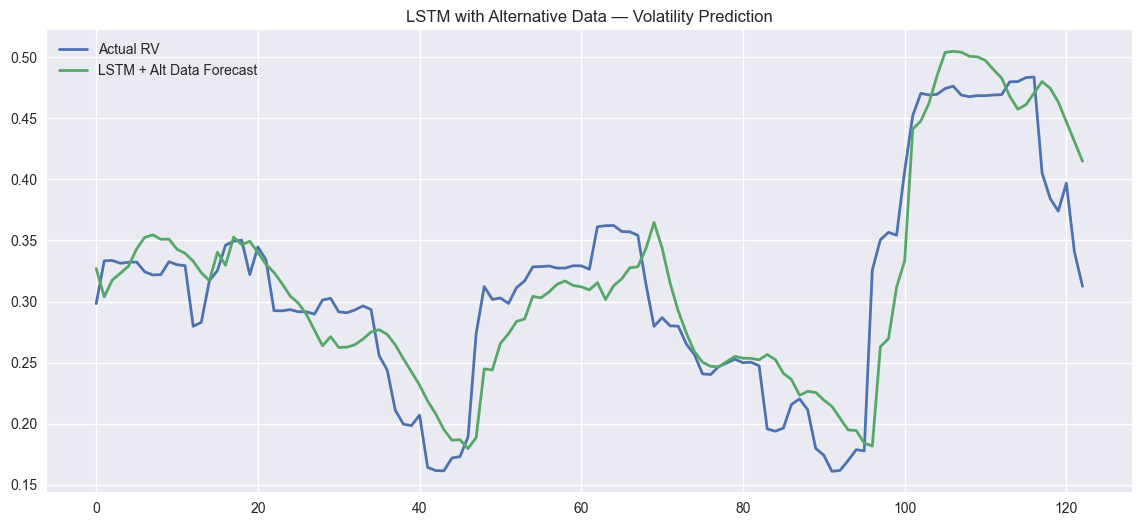


LSTM + Alt Data Performance:
MSE: 0.001589
MAE: 0.030760
Saved predictions to: ../data/processed/lstm_alt_predictions.csv


In [2]:
# ==========================================
# Notebook 07 — LSTM with Alternative Data
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os

plt.style.use("seaborn-v0_8")

# Load Engineered Dataset
data_path = "../data/processed/features.csv"
df = pd.read_csv(data_path, parse_dates=["Date"]).set_index("Date")

print("Loaded dataset:")
display(df.head())

# Selected Features
base_features = ["log_ret", "RV_21", "Parkinson_21"]

# Optional alt-data (only used if present)
optional_features = [
    "sentiment_mean",
    "sentiment_std",
    "news_volume",
    "google_trends_vix"
]
features = [col for col in base_features + optional_features if col in df.columns]
target = "RV_21"  

# Scale Features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features])

scaled_df = pd.DataFrame(scaled_features, index=df.index, columns=features)

# Convert to LSTM Sequences
def create_sequences(X, y, window=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - window):
        X_seq.append(X[i:i+window])
        y_seq.append(y[i+window])
    return np.array(X_seq), np.array(y_seq)

WINDOW = 30

X, y = create_sequences(
    scaled_df.values,
    df[target].values,
    window=WINDOW
)

# Train/Test Split (80% training - 20% testing)
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")

# Build LSTM Model
lstm_model = keras.Sequential([
    layers.Input(shape=(WINDOW, len(features))),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

# Train Model
history = lstm_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=25,
    batch_size=32,
    verbose=1
)

# Plot Training Curve
'''
This training curve shows how the model learns when we add alternative data. 

From the plot, the training loss drops very quickly in the first few epochs, 
which means the model is able to pick up the main patterns in the data right away. 
The validation loss stays slightly higher but follows a similar shape and remains stable, 
which is a good sign. 
Even though the validation curve moves up and down a bit, 
that behavior is normal for financial time series because markets are noisy. 

Overall, the gap between the two lines is small, suggesting that the model is not overfitting and is generalizing reasonably well. 
'''
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM + Alternative Data — Training Curve")
plt.legend()
plt.show()

# Make Predictions
y_pred = lstm_model.predict(X_test).flatten()

# Plot Forecast vs Actual
'''
This plot compares the actual realized volatility with the models forecasts. 

The forecast line generally follows the overall movements of the actual volatility, 
especially during calm or moderate periods. 
When volatility rises or falls gradually, the model stays close to the true values and captures the direction correctly. 
During sharp spikes, the model reacts but still lags a little, 
which is expected because sudden jumps in volatility are difficult for any model to predict. 

Compared to the baseline LSTM, this version produces smoother and more stable forecasts, 
suggesting that the extra features help the model respond better to changes in market conditions. 

Overall, the predictions show that alternative data improves the models ability to track real volatility dynamics.
'''
plt.figure(figsize=(14,6))
plt.plot(y_test, label="Actual RV", linewidth=2)
plt.plot(y_pred, label="LSTM + Alt Data Forecast", linewidth=2)
plt.title("LSTM with Alternative Data — Volatility Prediction")
plt.legend()
plt.show()

# Forecast Evaluation
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\nLSTM + Alt Data Performance:")
print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")

# Save Predictions
out_path = "../data/processed/lstm_alt_predictions.csv"
pd.DataFrame({
    "Actual_RV": y_test,
    "Pred_LSTM_Alt": y_pred
}).to_csv(out_path)

print("Saved predictions to:", out_path)